## Import Library

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import EfficientNet_B0_Weights
import os
import time
import copy
import matplotlib.pyplot as plt
import random
from PIL import Image
import io

# Record the start time
start_time = time.time()

## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Konfigurasi

In [3]:
FRAME_DIR = "/content/drive/MyDrive/datasetbaru/frame"
IMG_SIZE = (224, 224) # Ukuran input EfficientNetB0
BATCH_SIZE = 32
EPOCHS_INITIAL = 20
EPOCHS_FINE_TUNE = 30
INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


## Setup Dataset (Data Augmentasi & Face Recognition)

In [4]:
def apply_jpeg_compression(img):

    # 1. Buat buffer di memori (RAM)
    buffer = io.BytesIO()

    # 2. Simpan gambar ke buffer sebagai JPEG dengan kualitas acak
    kualitas = random.randint(40, 80)
    img.save(buffer, "JPEG", quality=kualitas)

    # 3. Pindahkan "pointer" buffer kembali ke awal
    buffer.seek(0)

    # 4. Buka kembali gambar yang sudah terkompresi dari buffer
    img_compressed = Image.open(buffer).convert("RGB")

    # 5. Tutup buffer
    buffer.close()

    return img_compressed

data_transforms = {
    'train': transforms.Compose([
        # Ganti RandomResizedCrop dengan Resize + RandomCrop agar skala wajah tetap terjaga
        transforms.Resize(256),
        transforms.RandomCrop(IMG_SIZE), # atau RandomResizedCrop dengan scale=(0.8, 1.0)
        transforms.RandomHorizontalFlip(),

        # 2. Augmentasi "penyiksaan" (bekerja pada PIL Image)
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),

        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=(3, 7))
        ], p=0.3),

        # 3. Augmentasi Kompresi JPEG (SEKARANG SUDAH AMAN)
        #    Menggunakan fungsi helper kita
        transforms.RandomApply([
            transforms.Lambda(apply_jpeg_compression)
        ], p=0.4),

        # 4. Konversi ke Tensor (setelah semua augmentasi di atas)
        transforms.ToTensor(),

        # 5. Normalisasi (setelah ToTensor)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    # 'validation' dan 'test' tetap sama (tidak perlu augmentasi)
    'validation': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

## Klasifikasi Variabel & Dataloader

In [5]:
print("Memuat data wajah...")
image_datasets = {x: datasets.ImageFolder(os.path.join(FRAME_DIR, x), data_transforms[x]) for x in ['train', 'validation', 'test']}
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'validation': DataLoader(image_datasets['validation'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'validation', 'test']}
class_names = image_datasets['train'].classes
print(f"Kelas ditemukan: {class_names} -> 'asli':0, 'deepfake':1")

Memuat data wajah...
Kelas ditemukan: ['asli', 'deepfake'] -> 'asli':0, 'deepfake':1


## Training Model

In [6]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Lists to store history
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        for phase in ['train', 'validation']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                labels = labels.float().view(-1, 1)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'validation' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        if phase == 'train' and scheduler: scheduler.step()
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

## Plot History

In [7]:
import matplotlib.pyplot as plt

def plot_history(train_loss, val_loss, train_acc, val_acc, title):
    epochs = range(len(train_loss))

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Transfer Learning EfficientNet

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 231MB/s]


Epoch 1/20
----------
train Loss: 0.6686 Acc: 0.5749
validation Loss: 0.6139 Acc: 0.7331

Epoch 2/20
----------
train Loss: 0.6168 Acc: 0.6739
validation Loss: 0.5778 Acc: 0.7213

Epoch 3/20
----------
train Loss: 0.6085 Acc: 0.6776
validation Loss: 0.5691 Acc: 0.7230

Epoch 4/20
----------
train Loss: 0.5846 Acc: 0.7038
validation Loss: 0.5489 Acc: 0.7517

Epoch 5/20
----------
train Loss: 0.5865 Acc: 0.6909
validation Loss: 0.5475 Acc: 0.7382

Epoch 6/20
----------
train Loss: 0.5821 Acc: 0.6980
validation Loss: 0.5440 Acc: 0.7382

Epoch 7/20
----------
train Loss: 0.5828 Acc: 0.6909
validation Loss: 0.5355 Acc: 0.7568

Epoch 8/20
----------
train Loss: 0.5759 Acc: 0.7022
validation Loss: 0.5422 Acc: 0.7297

Epoch 9/20
----------
train Loss: 0.5716 Acc: 0.7126
validation Loss: 0.5253 Acc: 0.7365

Epoch 10/20
----------
train Loss: 0.5450 Acc: 0.7284
validation Loss: 0.5383 Acc: 0.7331

Epoch 11/20
----------
train Loss: 0.5600 Acc: 0.7092
validation Loss: 0.5371 Acc: 0.7382

Epoch 12

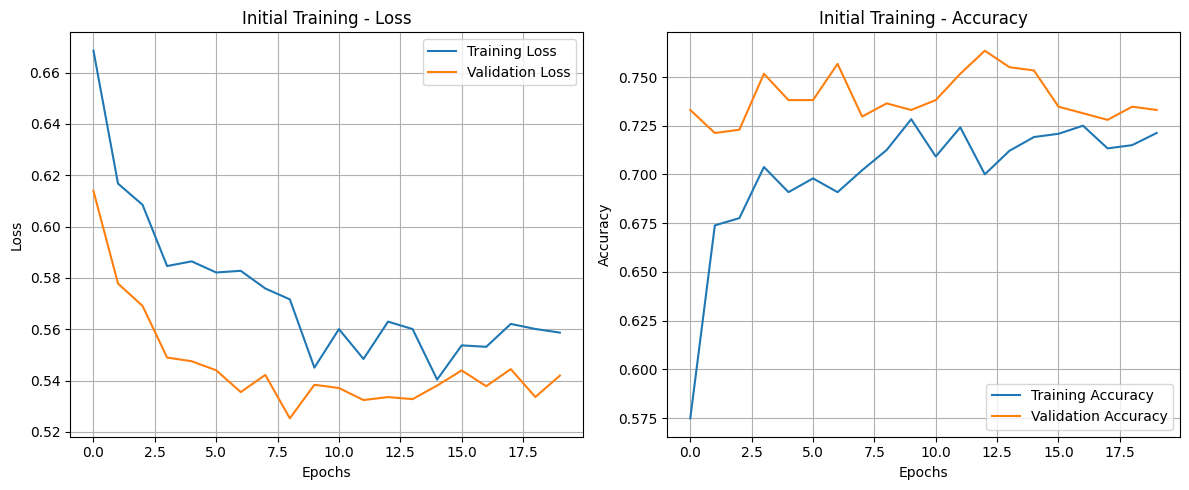

In [8]:
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights)

# Bekukan semua parameter base model
for param in model.features.parameters():
    param.requires_grad = False

# Ganti classifier
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.5),  # Matikan 50% neuron secara acak saat training
    nn.Linear(num_ftrs, 1)
)

model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=INITIAL_LR, weight_decay=1e-4)
optimizer_ft = optim.Adam(model.parameters(), lr=FINE_TUNE_LR, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Latih head
model, initial_train_loss, initial_val_loss, initial_train_acc, initial_val_acc = train_model(model, criterion, optimizer, lr_scheduler, num_epochs=EPOCHS_INITIAL)

# Plot history for initial training
plot_history(initial_train_loss, initial_val_loss, initial_train_acc, initial_val_acc, "Initial Training")

In [9]:
!pip install torchsummary

from torchsummary import summary

print("\n--- Model Summary ---")
# Pastikan model berada di device (CPU atau GPU) sebelum menampilkan summary
summary(model, input_size=(3, IMG_SIZE[0], IMG_SIZE[1]))


--- Model Summary ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2

## Fine Tuning Model


--- Fine-Tuning Seluruh Model ---
Epoch 1/30
----------
train Loss: 0.5422 Acc: 0.7304
validation Loss: 0.5089 Acc: 0.7736

Epoch 2/30
----------
train Loss: 0.5155 Acc: 0.7496
validation Loss: 0.5008 Acc: 0.7703

Epoch 3/30
----------
train Loss: 0.4913 Acc: 0.7675
validation Loss: 0.4759 Acc: 0.7821

Epoch 4/30
----------
train Loss: 0.4736 Acc: 0.7687
validation Loss: 0.4718 Acc: 0.7922

Epoch 5/30
----------
train Loss: 0.4446 Acc: 0.7924
validation Loss: 0.4594 Acc: 0.7855

Epoch 6/30
----------
train Loss: 0.4283 Acc: 0.8016
validation Loss: 0.4536 Acc: 0.7838

Epoch 7/30
----------
train Loss: 0.3972 Acc: 0.8265
validation Loss: 0.4479 Acc: 0.7939

Epoch 8/30
----------
train Loss: 0.3834 Acc: 0.8340
validation Loss: 0.4373 Acc: 0.7956

Epoch 9/30
----------
train Loss: 0.3706 Acc: 0.8428
validation Loss: 0.4152 Acc: 0.8209

Epoch 10/30
----------
train Loss: 0.3631 Acc: 0.8369
validation Loss: 0.4167 Acc: 0.8176

Epoch 11/30
----------
train Loss: 0.3328 Acc: 0.8644
validation

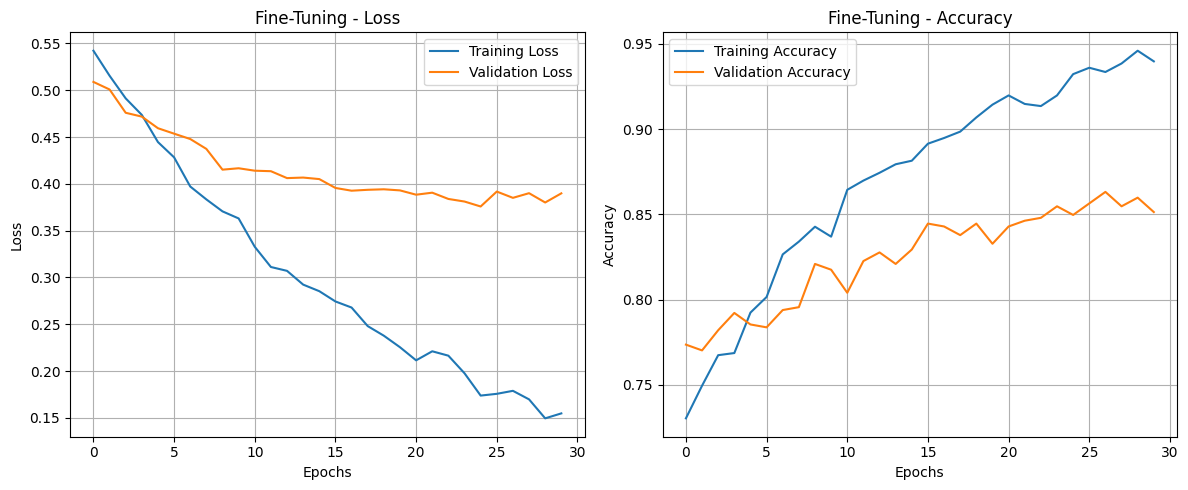

In [10]:
print("\n--- Fine-Tuning Seluruh Model ---")
for param in model.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(model.parameters(), lr=FINE_TUNE_LR)
lr_scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# Lanjutkan pelatihan
model, finetune_train_loss, finetune_val_loss, finetune_train_acc, finetune_val_acc = train_model(model, criterion, optimizer_ft, lr_scheduler_ft, num_epochs=EPOCHS_FINE_TUNE)

# Plot history for fine-tuning
plot_history(finetune_train_loss, finetune_val_loss, finetune_train_acc, finetune_val_acc, "Fine-Tuning")

## Evaluasi Model

In [11]:
print("\n--- EVALUASI AKHIR PADA TEST SET ---")
model.eval()
running_corrects = 0
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.float().view(-1, 1)
        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        running_corrects += torch.sum(preds == labels.data)

accuracy = running_corrects.double() / dataset_sizes['test']
print(f'Akurasi akhir pada test set: {accuracy.item() * 100:.2f}%')


--- EVALUASI AKHIR PADA TEST SET ---
Akurasi akhir pada test set: 77.81%



--- Confusion Matrix pada Test Set ---


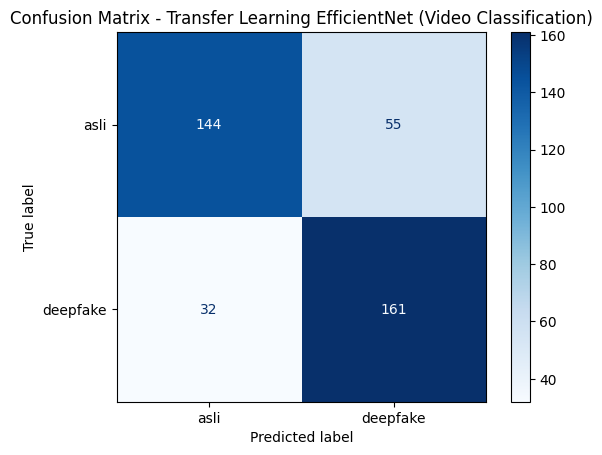

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

print("\n--- Confusion Matrix pada Test Set ---")
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_labels.extend(labels.data.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Transfer Learning EfficientNet (Video Classification)')
plt.show()

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

print("\n--- Metrik Evaluasi pada Test Set ---")
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_labels.extend(labels.data.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

y_true = np.array(all_labels)
y_pred_labels = np.array(all_preds)

precision = precision_score(y_true, y_pred_labels)
recall = recall_score(y_true, y_pred_labels)
f1 = f1_score(y_true, y_pred_labels)
accuracy = accuracy_score(y_true, y_pred_labels)

print(f"Akurasi  : {accuracy:.4f}")
print(f"Presisi  : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


--- Metrik Evaluasi pada Test Set ---
Akurasi  : 0.7781
Presisi  : 0.7454
Recall   : 0.8342
F1-Score : 0.7873


## Simpan Model Terbaik

In [14]:
torch.save(model.state_dict(), 'deepfake_detector_efficientnet.pth')
print("\nModel telah disimpan.")

end_time = time.time()
total_time = end_time - start_time
print(f"\nTotal waktu eksekusi: {total_time // 60:.0f}m {total_time % 60:.0f}s")


Model telah disimpan.

Total waktu eksekusi: 31m 17s


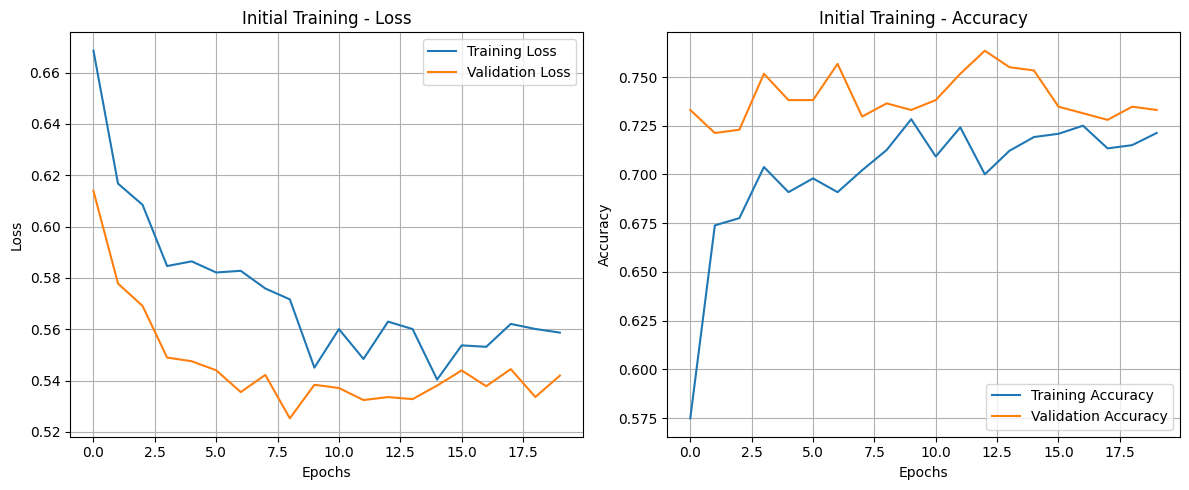

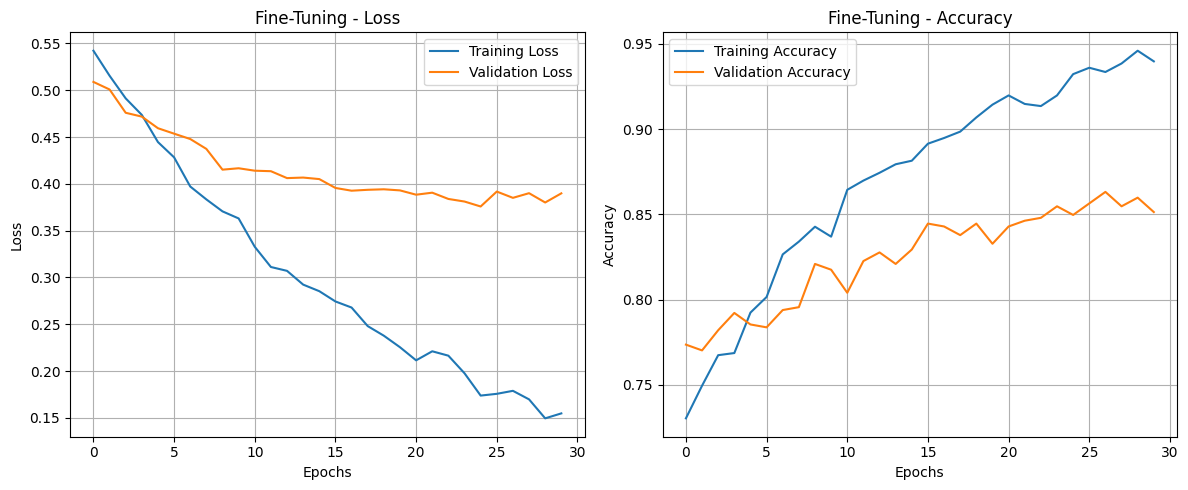

In [15]:
# Plot history for initial training
plot_history(initial_train_loss, initial_val_loss, initial_train_acc, initial_val_acc, "Initial Training")

# Plot history for fine-tuning
plot_history(finetune_train_loss, finetune_val_loss, finetune_train_acc, finetune_val_acc, "Fine-Tuning")

In [ ]:
# --- KONFIGURASI ---
# ---------------------
# 1. Tentukan Device
# 2. Siapkan Transformasi Data
# 3. Muat Data
# 4. Fungsi Pelatihan (Tidak berubah)
# 5. Bangun Model EfficientNetB0
# 6. Tahap 2: Fine-Tuning
# 7. Evaluasi Akhir pada Test Set